<h3> Relative trophoblast invasion from light sheet images </h3>

In [1]:
# import and formatting statements

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

plt.rcParams['pdf.fonttype'] = 42
sns.set(style="whitegrid", context="talk")

file_path = "Source_Data_CXCL12_placenta.xlsx"
df = pd.read_excel(file_path, sheet_name="Fig_1G")  



STATISTICAL ANALYSIS RESULTS

--- 1. 2D vs 3D within each stage (Independent t-test) ---
E6.5:	 t=4.634, p=0.0017 (*)
E8.5:	 t=2.911, p=0.0122 (*)
E12.5:	 t=28.379, p=0.0000 (*)
E14.5:	 Not enough data for t-test

--- 2. Across time points within 2D Ratio ---
[ANOVA] F=148.870, p=0.0000 (*)

[Post-Hoc: Tukey HSD for 2D Ratio]
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
 E12.5  E14.5   0.0017   1.0 -0.1015  0.1049  False
 E12.5   E6.5  -0.7578   0.0 -0.8877  -0.628   True
 E12.5   E8.5  -0.6184   0.0 -0.7366 -0.5001   True
 E14.5   E6.5  -0.7595   0.0 -0.8894 -0.6297   True
 E14.5   E8.5  -0.6201   0.0 -0.7383 -0.5019   True
  E6.5   E8.5   0.1395 0.056 -0.0026  0.2815  False
---------------------------------------------------

--- 3. Across time points within 3D Normalized ---
[ANOVA] F=51.249, p=0.0000 (*)

[Post-Hoc: Tukey HSD for 3D Normalized]
Multiple Comparison of Mean

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_9227/2311965655.py:101: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(
/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_9227/2311965655.py:115: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


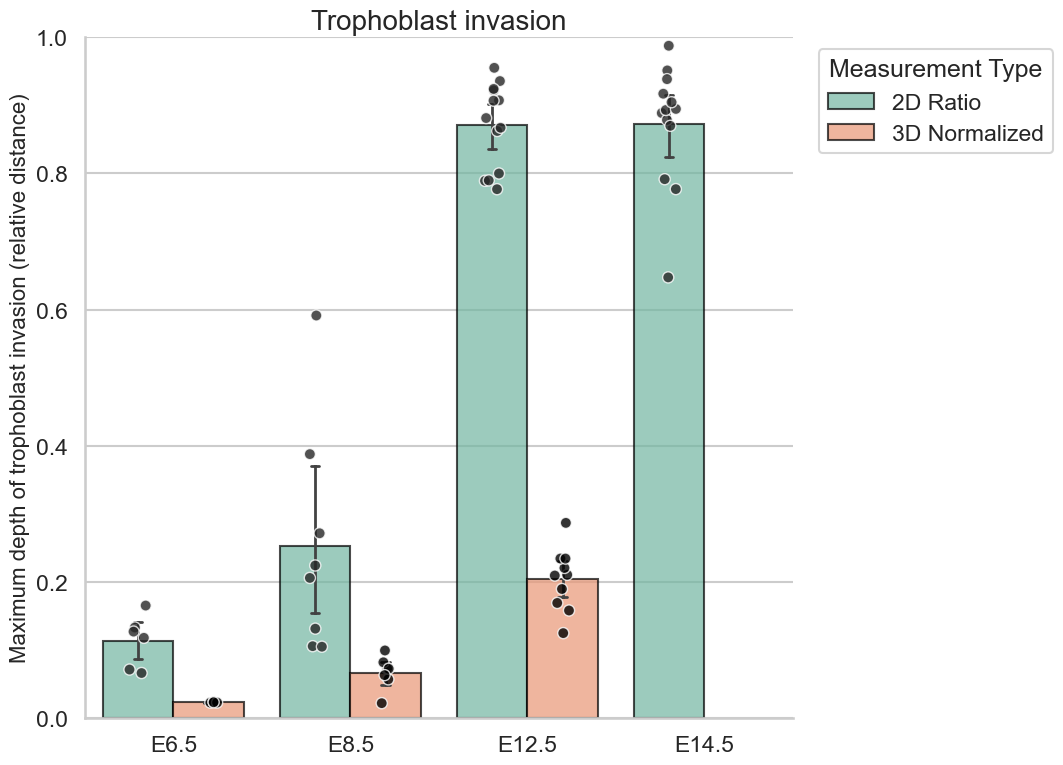

In [2]:
df.columns = df.columns.str.replace(' ', '_').str.replace('__', '_').str.strip()
stages = ["E6.5", "E8.5", "E12.5", "E14.5"]
ratio_data = []

for stage in stages:
    #2D sections
    myo_col = f"{stage}_myometrium"
    troph_col = f"{stage}_trophoblast"
    
    if myo_col in df.columns and troph_col in df.columns:
        ratios = (df[troph_col] / df[myo_col]).dropna()
        for r in ratios:
            ratio_data.append({
                'embryonic_stage': stage,
                'value': r,
                'Measurement Type': '2D Ratio'
            })
            
    # 3D normalized values
    norm_col = f"{stage}_normalized_section"
    if norm_col in df.columns:
        norms = df[norm_col].dropna()
        for n in norms:
            ratio_data.append({
                'embryonic_stage': stage,
                'value': n,
                'Measurement Type': '3D Normalized'
            })

plot_data = pd.DataFrame(ratio_data)

plot_data["embryonic_stage"] = pd.Categorical(
    plot_data["embryonic_stage"],
    categories=stages,
    ordered=True
)

# statistical tests

print("\n" + "="*50)
print("STATISTICAL ANALYSIS RESULTS")
print("="*50)

# 2D VS 3D (at every time point)
print("\n--- 1. 2D vs 3D within each stage (Independent t-test) ---")
for stage in stages:
    data_2d = plot_data[(plot_data['embryonic_stage'] == stage) & (plot_data['Measurement Type'] == '2D Ratio')]['value']
    data_3d = plot_data[(plot_data['embryonic_stage'] == stage) & (plot_data['Measurement Type'] == '3D Normalized')]['value']
    
    if len(data_2d) > 1 and len(data_3d) > 1:
        stat, p_val = stats.ttest_ind(data_2d, data_3d, nan_policy='omit')
        sig_marker = '*' if p_val < 0.05 else 'ns'
        print(f"{stage}:\t t={stat:.3f}, p={p_val:.4f} ({sig_marker})")
    else:
        print(f"{stage}:\t Not enough data for t-test")

# Across time 2D
print("\n--- 2. Across time points within 2D Ratio ---")
df_2d = plot_data[plot_data['Measurement Type'] == '2D Ratio'].dropna(subset=['value'])
groups_2d = [df_2d[df_2d['embryonic_stage'] == stage]['value'] for stage in stages if not df_2d[df_2d['embryonic_stage'] == stage].empty]

if len(groups_2d) > 1:
    stat, p_val = stats.f_oneway(*groups_2d)
    sig_marker = '*' if p_val < 0.05 else 'ns'
    print(f"[ANOVA] F={stat:.3f}, p={p_val:.4f} ({sig_marker})")
    
    if p_val < 0.05:
        print("\n[Post-Hoc: Tukey HSD for 2D Ratio]")
        tukey_2d = pairwise_tukeyhsd(endog=df_2d['value'], groups=df_2d['embryonic_stage'], alpha=0.05)
        print(tukey_2d)
    else:
        print("ANOVA is not significant; skipping post-hoc test.")
else:
    print("Not enough stage groups for ANOVA in 2D data.")

# Across time 3D
print("\n--- 3. Across time points within 3D Normalized ---")
df_3d = plot_data[plot_data['Measurement Type'] == '3D Normalized'].dropna(subset=['value'])
groups_3d = [df_3d[df_3d['embryonic_stage'] == stage]['value'] for stage in stages if not df_3d[df_3d['embryonic_stage'] == stage].empty]

if len(groups_3d) > 1:
    stat, p_val = stats.f_oneway(*groups_3d)
    sig_marker = '*' if p_val < 0.05 else 'ns'
    print(f"[ANOVA] F={stat:.3f}, p={p_val:.4f} ({sig_marker})")
    
    if p_val < 0.05:
        print("\n[Post-Hoc: Tukey HSD for 3D Normalized]")
        tukey_3d = pairwise_tukeyhsd(endog=df_3d['value'], groups=df_3d['embryonic_stage'], alpha=0.05)
        print(tukey_3d)
    else:
        print("ANOVA is not significant; skipping post-hoc test.")
else:
     print("Not enough stage groups for ANOVA in 3D data.")

print("="*50 + "\n")


plt.figure(figsize=(11, 8))
ax = plt.gca()

sns.barplot(
    data=plot_data, 
    x="embryonic_stage", 
    y="value", 
    hue="Measurement Type", 
    capsize=0.1, 
    errwidth=2,
    edgecolor="black",
    linewidth=1.5,
    alpha=0.7,
    palette="Set2",
    ax=ax
)

sns.stripplot(
    data=plot_data, 
    x="embryonic_stage", 
    y="value", 
    hue="Measurement Type",
    dodge=True,            
    color="black", 
    size=8, 
    alpha=0.8,
    edgecolor="white",
    linewidth=1,
    jitter=True,
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
unique_labels = plot_data['Measurement Type'].unique()
ax.legend(
    handles[:len(unique_labels)], 
    labels[:len(unique_labels)], 
    title="Measurement Type", 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left'
)

# Label axes and set titles
ax.set_xlabel("")
ax.set_ylabel("Maximum depth of trophoblast invasion (relative distance)", fontsize=16)
ax.set_title("Trophoblast invasion", fontsize=20)
ax.set_ylim(0, 1)

sns.despine()
plt.tight_layout() 
plt.show()